In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

In [68]:
df=pd.read_csv("/content/Electric_Vehicle_Population_Data.csv")

In [69]:
len(df)

285822

In [70]:
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,WBY2Z2C57G,Yakima,Yakima,WA,98908.0,2016,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,14.0,232628763,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
1,5YJYGDEE8M,Yakima,Selah,WA,98942.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,236581355,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
2,JTDKN3DP9D,Snohomish,Marysville,WA,98271.0,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6.0,38.0,211956958,POINT (-122.17138 48.10433),PUGET SOUND ENERGY INC,5.306105e+10
3,WP1AE2AY6M,Yakima,Yakima,WA,98908.0,2021,PORSCHE,CAYENNE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,14.0,271976883,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
4,LPSED3KA5M,Kitsap,Bainbridge Island,WA,98110.0,2021,POLESTAR,PS2,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,233.0,23.0,255446103,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10


In [71]:
#Data cleaning

In [72]:
print("### SECTION 1: DATA CLEANING ###\n")


### SECTION 1: DATA CLEANING ###



In [73]:
# 1. Loading data with encoding fix
df = pd.read_csv('Electric_Vehicle_Population_Data.csv', encoding='utf-8')


In [74]:
# Q: How many missing values exist?
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         8
Legislative District                                 733
DOL Vehicle ID                                         0
Vehicle Location                                      18
Electric Utility                                      10
2020 Census Tract                                     10
dtype: int64


In [75]:
df['County']=df['County'].fillna('Unknown')
df['City']=df['City'].fillna('Unknown')

In [76]:
# Q: Handling missing or zero values in Base MSRP and Electric Range
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].mean())


In [77]:
print(df.columns.tolist())

['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [78]:
# Q: Checking and managing duplicates
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [79]:
# Q: Anonymize VINs while maintaining uniqueness (using SHA-256 hashing)
df['Anonymized_VIN'] = df['VIN (1-10)'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:10])


In [80]:
# Q: Clean Vehicle Location (GPS Coordinates)
df['Longitude'] = df['Vehicle Location'].str.extract(r'POINT \((-\d+\.\d+)')
df['Latitude'] = df['Vehicle Location'].str.extract(r'POINT \(-\d+\.\d+ (\d+\.\d+)')
df['Longitude'] = pd.to_numeric(df['Longitude']).fillna(0)
df['Latitude'] = pd.to_numeric(df['Latitude']).fillna(0)


In [81]:
print("\nData Cleaning Completed Successfully!\n")



Data Cleaning Completed Successfully!



In [82]:
# SECTION 2: DATA EXPLORATION
print("### SECTION 2: DATA EXPLORATION ###\n")


### SECTION 2: DATA EXPLORATION ###



In [83]:
# Q: Top 5 most common EV makes and models
print("Top 5 EV Makes:\n", df['Make'].value_counts().head(5))
print("\nTop 5 EV Models:\n", df['Model'].value_counts().head(5))


Top 5 EV Makes:
 Make
TESLA        117392
CHEVROLET     19677
NISSAN        16121
FORD          15639
KIA           14328
Name: count, dtype: int64

Top 5 EV Models:
 Model
MODEL Y    62154
MODEL 3    38316
LEAF       13478
MODEL S     7815
BOLT EV     7693
Name: count, dtype: int64


In [84]:
# Q: Distribution of EVs by county (Top 5)
print("\nTop 5 Counties with most registrations:\n", df['County'].value_counts().head(5))



Top 5 Counties with most registrations:
 County
King         140181
Snohomish     35806
Pierce        23596
Clark         17638
Thurston      10404
Name: count, dtype: int64


In [85]:
# Q: Average electric range of EVs
print(f"\nAverage Electric Range: {df['Electric Range'].mean():.2f} miles")



Average Electric Range: 107.40 miles


In [86]:
# Q: Percentage of EVs eligible for CAFV incentives
cafv_pct = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts(normalize=True) * 100
print("\nCAFV Eligibility Percentage:\n", cafv_pct)



CAFV Eligibility Percentage:
 Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    64.476142
Clean Alternative Fuel Vehicle Eligible                         27.117577
Not eligible due to low battery range                            8.406281
Name: proportion, dtype: float64


In [87]:
# SECTION 3: DATA VISUALIZATION
print("\n### SECTION 3: DATA VISUALIZATION (Generating plots...) ###\n")



### SECTION 3: DATA VISUALIZATION (Generating plots...) ###



/tmp/ipykernel_16814/116925526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Make'].value_counts().head(5).index, y=df['Make'].value_counts().head(5).values, palette='viridis')


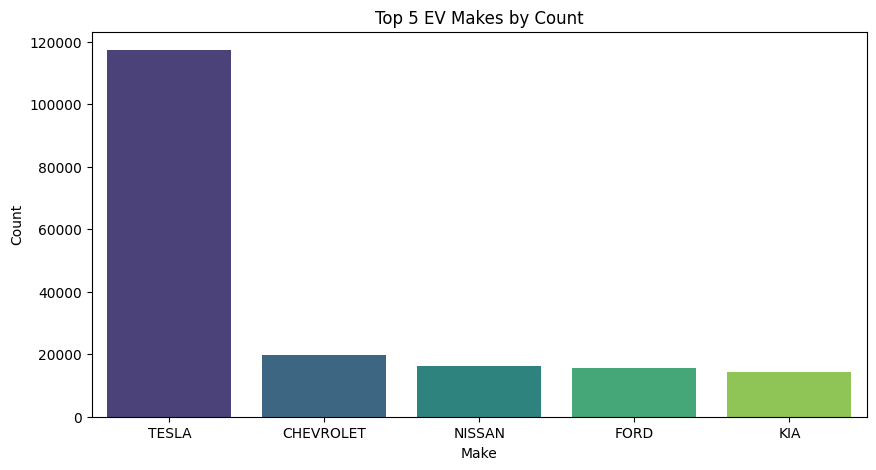

In [88]:
# 1. Bar chart showing top 5 EV makes
plt.figure(figsize=(10, 5))
sns.barplot(x=df['Make'].value_counts().head(5).index, y=df['Make'].value_counts().head(5).values, palette='viridis')
plt.title('Top 5 EV Makes by Count')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()


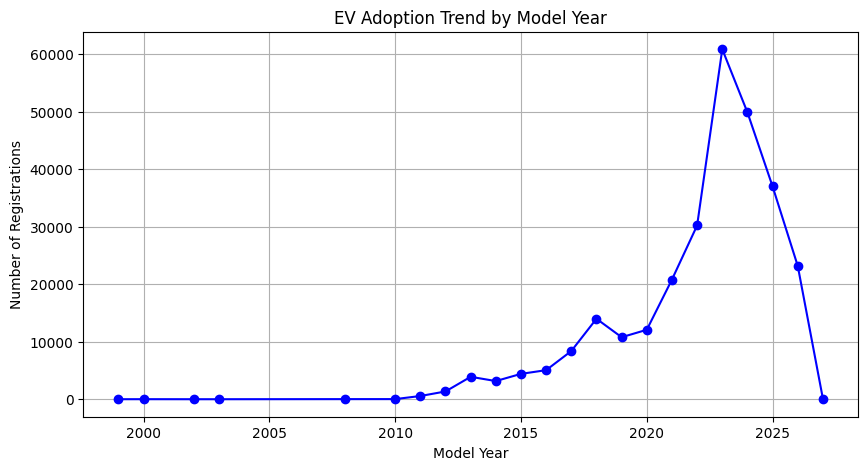

In [89]:
# 2. Line graph showing the trend of EV adoption by model year
plt.figure(figsize=(10, 5))
df['Model Year'].value_counts().sort_index().plot(kind='line', marker='o', color='b')
plt.title('EV Adoption Trend by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Registrations')
plt.grid(True)
plt.show()


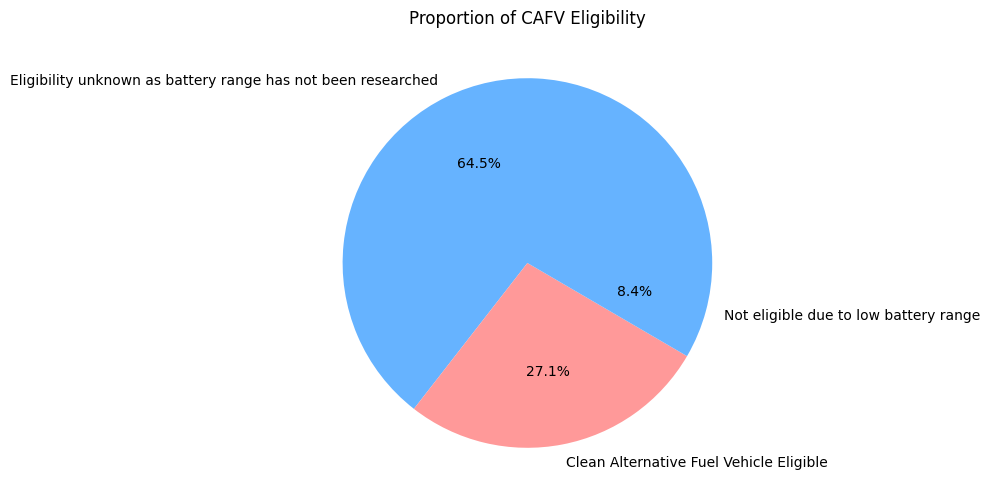

In [90]:
# 4. Pie chart showing the proportion of CAFV-eligible vs non-eligible EVs
plt.figure(figsize=(6, 6))
df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Proportion of CAFV Eligibility')
plt.ylabel('')
plt.show()


In [91]:
# SECTION 4: LINEAR REGRESSION MODEL
print("### SECTION 4: LINEAR REGRESSION MODEL ###\n")


### SECTION 4: LINEAR REGRESSION MODEL ###



In [92]:
df = pd.get_dummies(df, columns=['Make'], drop_first=True)


In [93]:
# Data Splitting (80% Training, 20% Testing)
# Define features (X) and target (y) after one-hot encoding 'Make' in df
X = df.filter(regex='^(Model Year|Make_).*')
y = df['Electric Range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
# Training the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [95]:
# Model Prediction & Evaluation
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)


In [97]:
print(f"\nModel Trained Successfully using ModelYear and Make.")
print(f"Model R² (R-squared) Score: {r2:.4f}")


Model Trained Successfully using ModelYear and Make.
Model R² (R-squared) Score: 0.3369
